In [1]:
!pip install rioxarray geopandas cartopy pymannkendall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.9 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
import xarray as xr
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pymannkendall as mk
import numpy as np
from scipy.stats import linregress

Resolution Check

In [3]:
#Resolution Check
sm_raw = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Soil Moisture/SoilMoisture_2000_2024_Monthly.nc")
print(sm_raw)

lat = sm_raw["lat"].values
lon = sm_raw["lon"].values

lat_res = abs(lat[1] - lat[0])
lon_res = abs(lon[1] - lon[0])


print("Lat resolution ~", lat_res, "degrees")
print("Lon resolution ~", lon_res, "degrees at equator")

<xarray.Dataset> Size: 4GB
Dimensions:     (time: 300, lat: 720, lon: 1440)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2024-12-01
  * lat         (lat) float32 3kB 89.88 89.62 89.38 ... -89.38 -89.62 -89.88
  * lon         (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    sm          (time, lat, lon) float32 1GB ...
    sensor      (time, lat, lon) int32 1GB ...
    freqbandID  (time, lat, lon) int16 622MB ...
    nobs        (time, lat, lon) float32 1GB ...
Attributes: (12/44)
    title:                        C3S Satellite Surface Soil Moisture merged ...
    institution:                  TU Wien (AUT); Planet Labs (NL); EODC Gmbh ...
    contact:                      C3S_SM_Science@eodc.eu
    source:                       WARP 5.5R1.1/AMI-WS/ERS12 Level 2 Soil Mois...
    platform:                     Nimbus 7, DMSP, TRMM, AQUA, Coriolis, GCOM-...
    processing_level:             Quality-controlled, super-colloca

Nearest Neighbor Interpolation to 0.25 degree cell

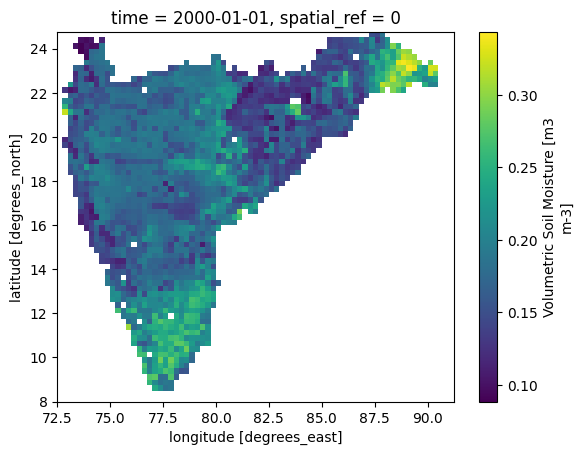

In [ ]:
sm_raw = sm_raw.rio.write_crs("EPSG:4326")  # lat/lon WGS84
sm_raw = sm_raw.rio.set_spatial_dims(x_dim="lon", y_dim="lat")

gdf = gpd.read_file("/content/drive/MyDrive/GNR644 - Water Balance/Data/PeninsularIndia/peninsularIndia_lvl3.shp")
gdf = gdf.to_crs("EPSG:4326")  # must match NetCDF CRS

# Select the main data variable ('satellite_precip') and explicitly set its spatial dimensions before clipping
sm_025 = sm_raw["sm"].rio.write_crs("EPSG:4326").rio.set_spatial_dims(x_dim="lon", y_dim="lat").rio.clip(gdf.geometry, gdf.crs, drop=True)

# Plotting the clipped variable
sm_025.isel(time=0).plot()

# Save the clipped variable to a new NetCDF file
#sm_025.to_netcdf("/content/drive/MyDrive/GNR644 - Water Balance/Data/Soil Moisture/SoilMoisture_Crop.nc")

Monthly Mean Analysis

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


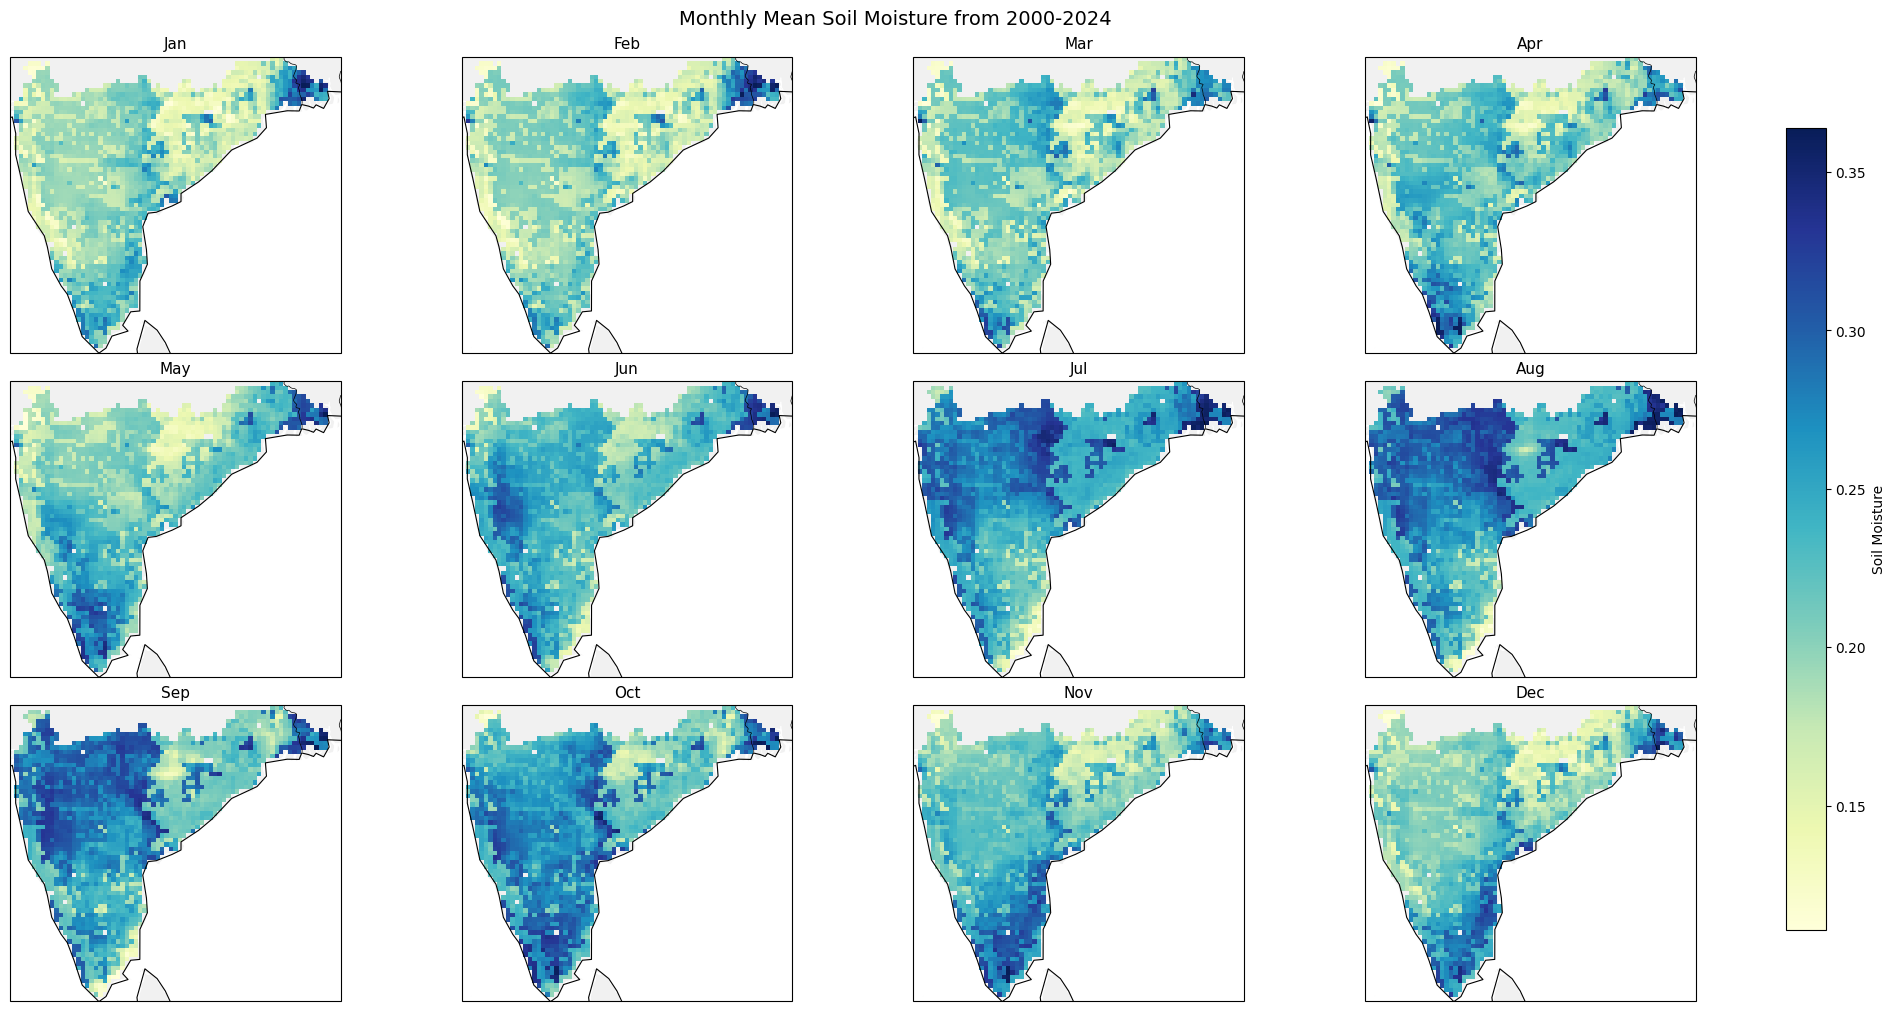

In [4]:
# -------------------------------
# Load NetCDF
# -------------------------------
sm_025 = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Soil Moisture/SoilMoisture_Crop.nc")
sm = sm_025["sm"]   # change variable name if needed

# -------------------------------
# Monthly climatology
# -------------------------------
monthly_mean = sm.groupby("time.month").mean(dim="time")

# -------------------------------
# Plot settings
# -------------------------------
projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="YlGnBu",
        add_colorbar=False
    )

    # Base map features
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    ax.set_title(months[i], fontsize=11)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Soil Moisture")

plt.suptitle(
    "Monthly Mean Soil Moisture from 2000-2024",
    fontsize=14
)


plt.show()


Monthly Mann Kendall Trend Analysis

In [6]:
# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:   # safety check
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
results = {}

for month in range(1, 13):

    sm_m = sm.sel(time=sm["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        sm_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })

# -------------------------------
# Example: January trend map
# -------------------------------
results[1]

<xarray.Dataset> Size: 161kB
Dimensions:     (lat: 67, lon: 75)
Coordinates:
  * lat         (lat) float32 268B 24.62 24.38 24.12 23.88 ... 8.625 8.375 8.125
  * lon         (lon) float32 300B 72.62 72.88 73.12 73.38 ... 90.62 90.88 91.12
Data variables:
    trend       (lat, lon) object 40kB nan nan nan nan nan ... nan nan nan nan
    z_value     (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan
    p_value     (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan
    sens_slope  (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan

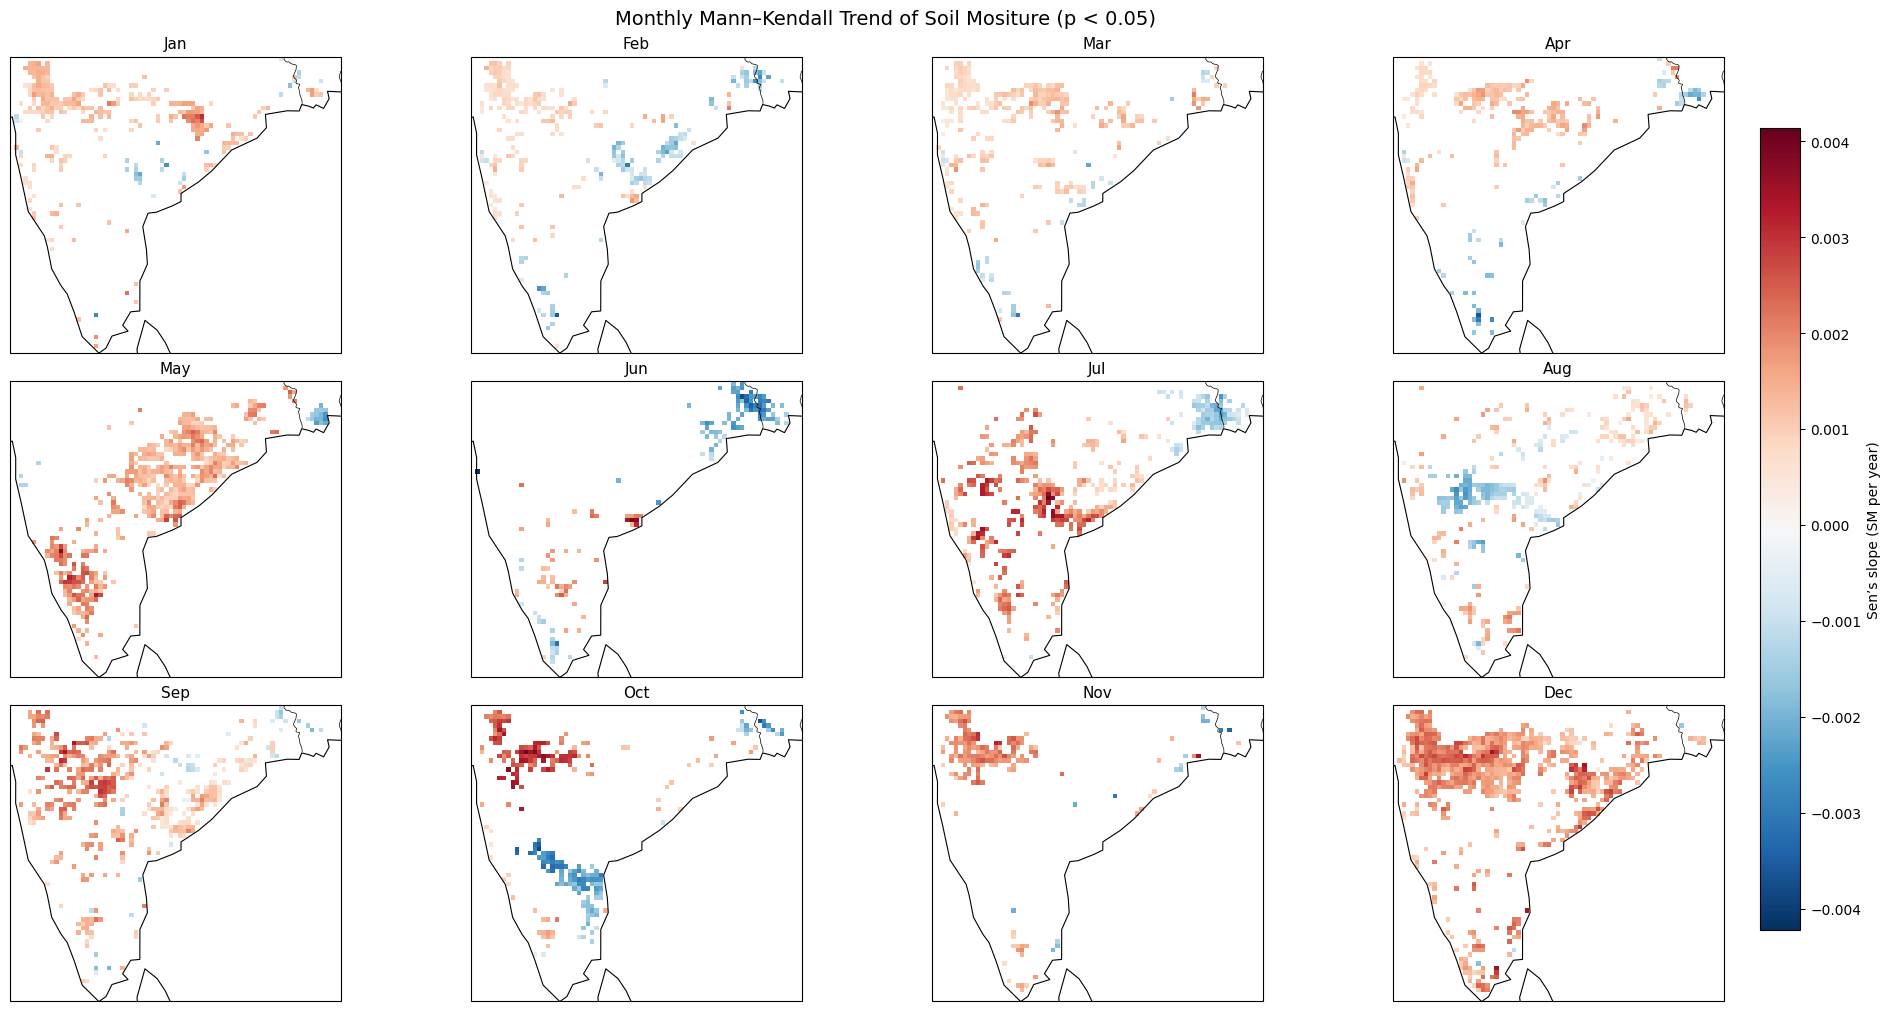

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (important)
# ---------------------------------
all_slopes = []

for m in range(1, 13):
    slope = results[m]["sens_slope"]
    sig = slope.where(results[m]["p_value"] < 0.05)
    all_slopes.append(sig)

vmin = np.nanmin([s.min().values for s in all_slopes])
vmax = np.nanmax([s.max().values for s in all_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1

    ds_mk = results[month]

    sig_slope = ds_mk["sens_slope"].where(
        ds_mk["p_value"] < 0.05
    )

    im = sig_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Basemap
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional: restrict extent (example: India)
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)
cbar.set_label("Sen’s slope (SM per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Soil Mositure (p < 0.05)",
    fontsize=14
)

plt.show()


Time Series Graph of Mean

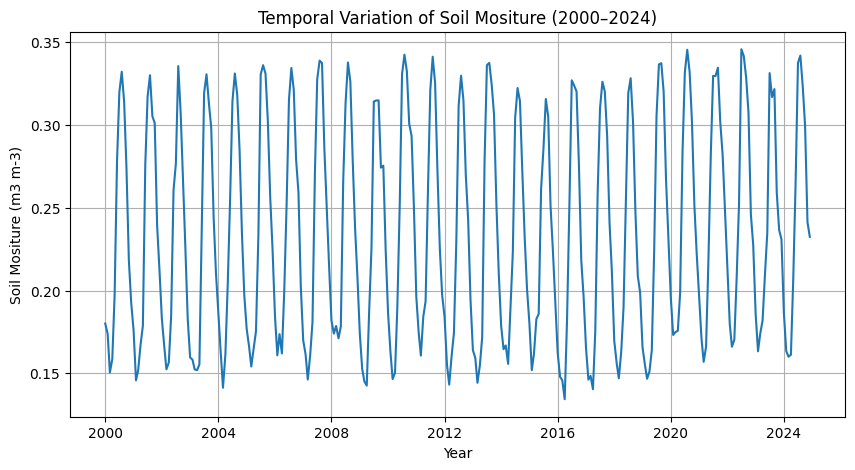

In [ ]:
sm_ts = sm.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

sm_ts.plot(label='Soil Moisture')

plt.title("Temporal Variation of Soil Mositure (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Soil Mositure (m3 m-3)")
plt.grid(True)

plt.show()

Grouping of Mean by month

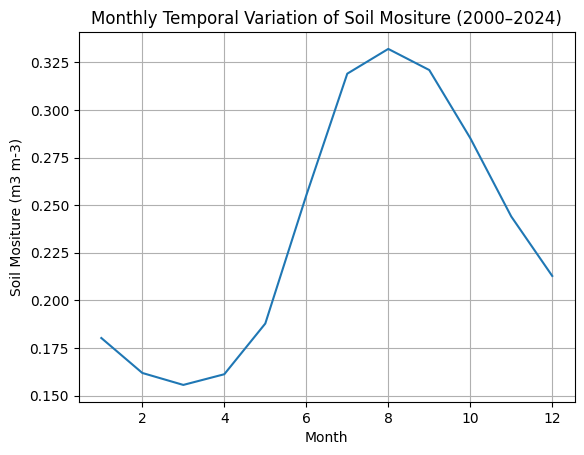

In [ ]:
sm_season = sm_ts.groupby('time.month').mean()
sm_season.plot(label='Soil Moisture')
plt.title("Monthly Temporal Variation of Soil Mositure (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Soil Mositure (m3 m-3)")
plt.grid(True)

Trend Analysis

In [ ]:
time_sm = np.arange(len(sm_ts))

slope, intercept, r, p, std = linregress(time_sm, sm_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 5.044874988302503e-05
p-value: 0.25274148325872087


Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [ ]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for Soil moisture from 2000 to 2024')

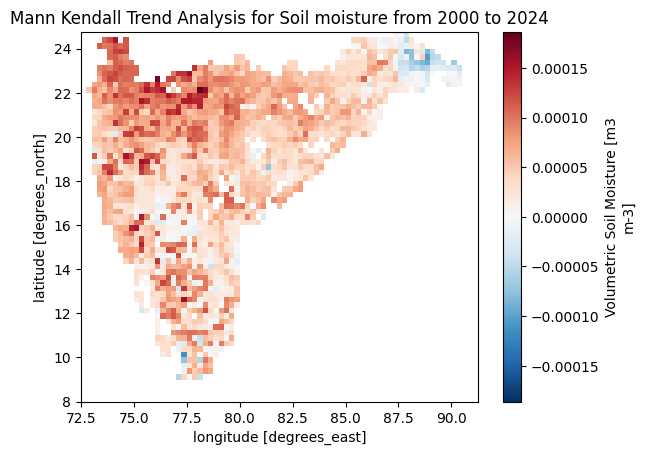

In [ ]:
sm_trend = xr.apply_ufunc(
    trend_calc,
    sm,
    input_core_dims=[['time']],
    vectorize=True
)

sm_trend.plot()
plt.title("Mann Kendall Trend Analysis for Soil moisture from 2000 to 2024")

Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for Soil Moisture')

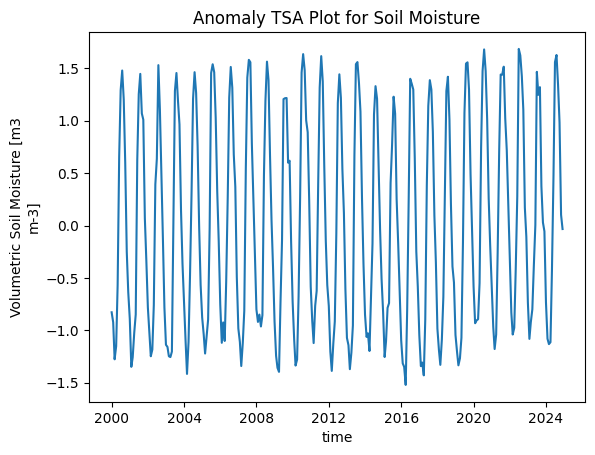

In [ ]:
sm_mean = sm_ts.mean()
sm_std = sm_ts.std()
sm_std_anomaly = (sm_ts - sm_mean) / sm_std
sm_std_anomaly.plot()
plt.title("Anomaly TSA Plot for Soil Moisture")